In [138]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import statistics as st

result = "../Outputs/Snapshots/snapshot.json"

In [139]:
def plot_throughput(ax, result, label, fontsize, add_WL=None):
    with open(result) as f:
        res = json.load(f)

    if add_WL is not None:
        ax.plot(add_WL, "--r", markersize=3, label="Workload", linewidth=1)

    tps_per_node = {}
    metric = "throughput"
    for interval in res.values():
        for i, value in enumerate(interval["metrics"][metric].values()):
            tps_per_node[i] = tps_per_node.get(i, []) + [value]

    data = np.array(list(tps_per_node.values()))

    mean_data = np.mean(data.T, axis=1)
    mean_data = data[2]

    ax.plot(mean_data, "--", label=label, markersize=3, zorder=4, linewidth=1)

    ax.grid(alpha=0.5)

    ax.set_ylabel("TPS", fontsize=fontsize)
    ax.set_xlabel("Snapshot", fontsize=fontsize)
    ax.legend(fontsize=fontsize_small, ncol=3, loc="upper left")

In [140]:
def plot_gini(ax, result, label, fontsize):
    with open(result) as f:
        data = json.load(f)

    tps_per_node = {}
    metric = "decentralisation"
    for interval in data.values():
        for i, value in enumerate(interval["metrics"][metric].values()):
            tps_per_node[i] = tps_per_node.get(i, []) + [value]

    data = np.array(list(tps_per_node.values()))

    ax.plot(np.mean(data, axis=0), "-", markersize=3, linewidth=1, label=label)

    ax.set_ylabel("Decentralisation", fontsize=fontsize)
    ax.set_xlabel("Snapshot", fontsize=fontsize)
    ax.legend(fontsize=fontsize_small, ncol=3, loc="upper left")
    ax.grid(alpha=0.5)

In [141]:
def plot_latency(ax, result, label, fontsize):
    with open(result) as f:
        data = json.load(f)

    tps_per_node = {}
    metric = "latency"
    for interval in data.values():
        for i, value in enumerate(interval["metrics"][metric].values()):
            tps_per_node[i] = tps_per_node.get(i, []) + [value["AVG"]]

    data = np.array(list(tps_per_node.values()))

    mean_data = np.mean(data.T, axis=1)

    ax.plot(mean_data, "--", label=label, markersize=3, linewidth=1)

    ax.grid(alpha=0.5)
    ax.legend(fontsize=fontsize_small, ncol=3, loc="upper left")
    ax.set_ylabel("Transaction Latency (S)", fontsize=fontsize)
    ax.set_xlabel("Snapshot", fontsize=fontsize)

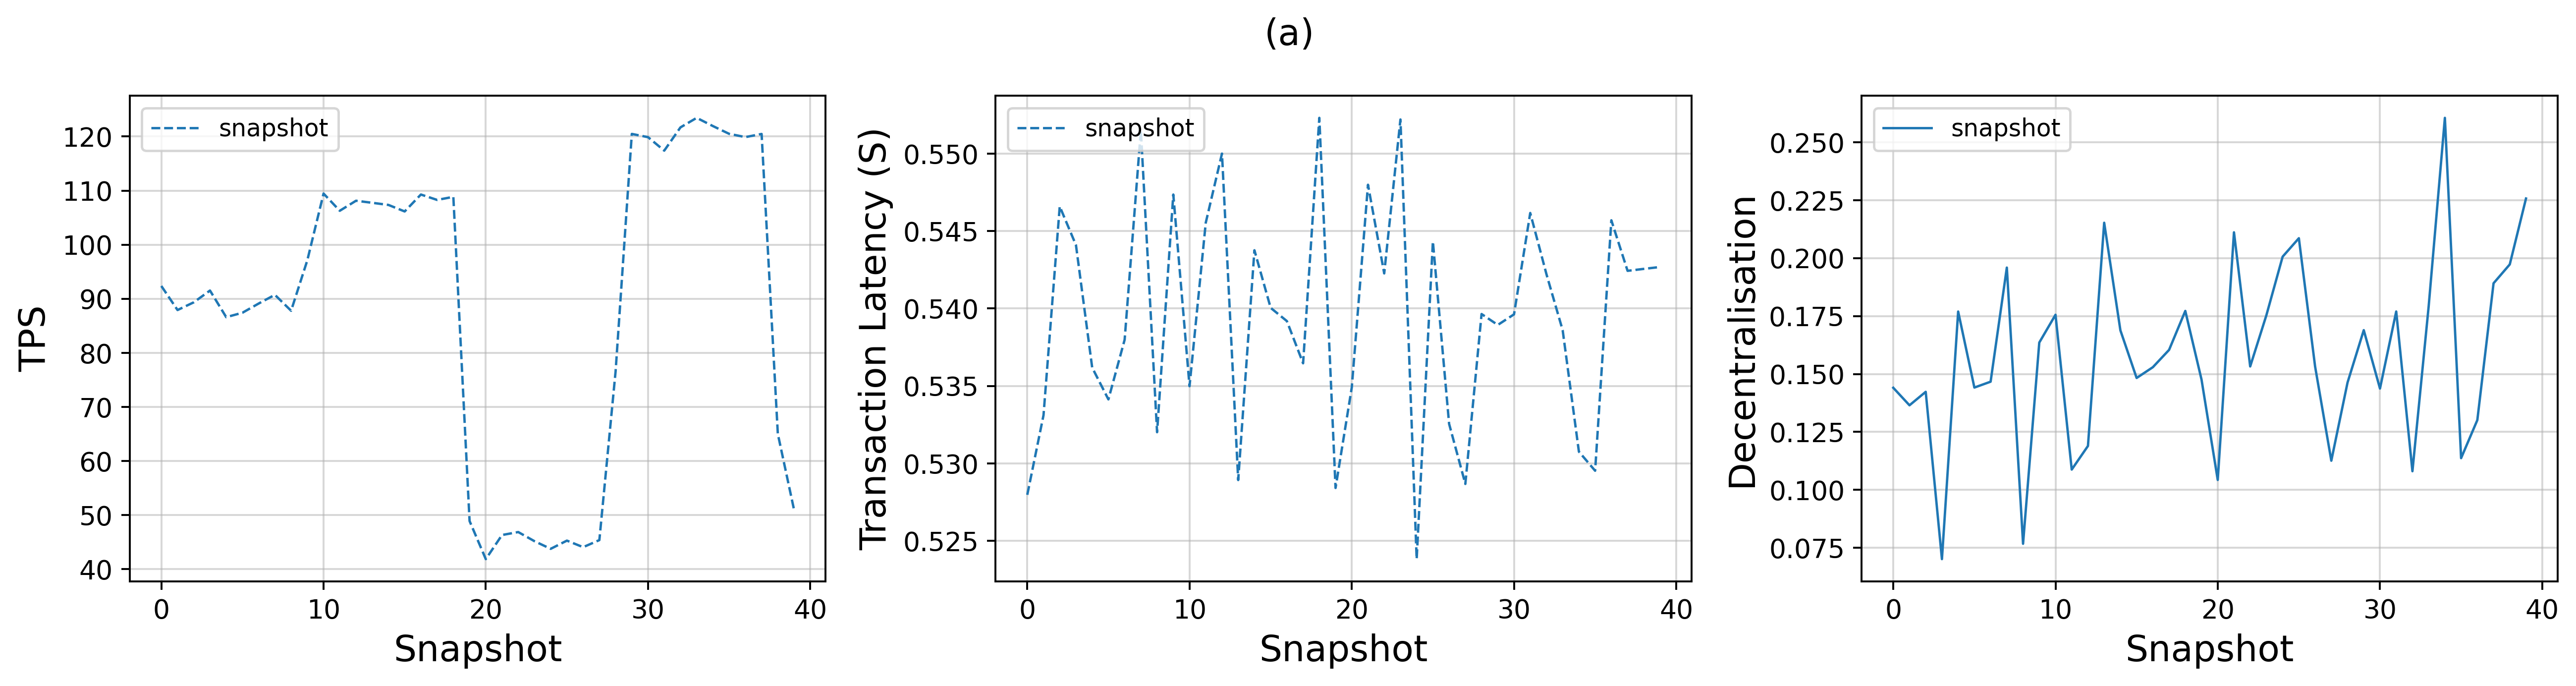

In [142]:
fig, axes = plt.subplots(1, 3)
fig.set_figwidth(15)
fig.set_figheight(4)
fig.set_dpi(350)

fontsize = 15
fontsize_small = 10
matplotlib.rcParams["font.size"] = 11

legend = result.split("/")[-1].split(".")[0]

plot_throughput(axes[0], result, legend, fontsize)
plot_latency(axes[1], result, legend, fontsize)
plot_gini(axes[2], result, legend, fontsize)

plt.suptitle("(a)", fontsize=fontsize)
plt.tight_layout()